### Đồ án cuối kỳ: Phân loại tin nhắn rác (SMS Spam Classification)
# "LSTM Master" 

## 0. Cài đặt môi trường & Import thư viện

In [3]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input, Embedding, LSTM, GRU, Bidirectional, SpatialDropout1D, Dense, Dropout
)
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score

import tensorflow as tf

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

## 1. Chuẩn bị dữ liệu 

In [4]:
df = pd.read_csv('sms+spam+collection/SMSSpamCollection', sep='\t', header=None, names=['Label', 'Text'])
df['Label'] = df['Label'].map({'ham': 0, 'spam': 1})

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)
    return text

df['Clean_Text'] = df['Text'].apply(clean_text)

max_words = 10000
tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(df['Clean_Text'])
sequences = tokenizer.texts_to_sequences(df['Clean_Text'])

max_len = 100
X_padded = pad_sequences(sequences, maxlen=max_len, padding='post', truncating='post')
Y = df['Label'].values

X_train, X_test, Y_train, Y_test = train_test_split(
    X_padded, Y, test_size=0.2, random_state=SEED, stratify=Y
)

print('Số tin nhắn để HỌC (Train):', len(X_train))
print('Số tin nhắn để THI (Test):', len(X_test))

Số tin nhắn để HỌC (Train): 4457
Số tin nhắn để THI (Test): 1115


## 2. Xây dựng mô hình (tổng quát hoá cho LSTM / GRU / Bidirectional)

Hàm `build_rnn_model` giờ nhận thêm 3 tham số mới:
- `cell_type`: `'lstm'` hoặc `'gru'` — chọn loại tầng hồi tiếp.
- `bidirectional`: có bọc `Bidirectional(...)` hay không.
- `recurrent_dropout`: tỉ lệ dropout áp dụng ngay trong tầng hồi tiếp (giữa các bước thời gian), khác với `Dropout` thường (chỉ áp dụng sau khi ra khỏi tầng).

### FIX #5 — Thêm `Input(shape=(max_len,))` tường minh

Trong Keras 3, nếu `Sequential` bắt đầu bằng `Embedding` mà không khai báo `Input` rõ ràng, model chỉ thực sự "build" (xác định shape + khởi tạo trọng số) ở lần gọi `.fit()`/`.predict()` đầu tiên. Gọi `model.summary()` trước đó sẽ chỉ in ra `Output Shape = ?` và `Param # = 0 (unbuilt)` — dù model vẫn huấn luyện bình thường phía sau. Thêm `Input(shape=(max_len,))` làm lớp đầu tiên giúp model được build ngay lập tức, `summary()` hiển thị đúng ngay khi gọi.

In [5]:
embedding_dim = 64

def build_rnn_model(
    units=32,
    cell_type='lstm',            # 'lstm' hoặc 'gru'
    bidirectional=False,
    use_dropout=False,
    dropout_rate=0.5,
    recurrent_dropout=0.0,
    spatial_dropout=0.0,
):
    """
    Khởi tạo mô hình RNN (LSTM hoặc GRU, có thể Bidirectional) để phân loại SMS Spam/Ham.

    Tham số
    ----------
    units : int
        Số hidden units của tầng hồi tiếp.
    cell_type : str
        'lstm' hoặc 'gru'.
    bidirectional : bool
        Bọc tầng hồi tiếp trong Bidirectional hay không.
    use_dropout : bool
        Thêm Dropout thường sau tầng hồi tiếp hay không.
    dropout_rate : float
        Tỉ lệ Dropout thường (chỉ dùng khi use_dropout=True).
    recurrent_dropout : float
        Tỉ lệ dropout áp dụng trong nội bộ tầng hồi tiếp (giữa các time step).
    spatial_dropout : float
        Tỉ lệ SpatialDropout1D ngay sau Embedding (drop nguyên chiều embedding của một số từ).

    Trả về
    -------
    tf.keras.Model đã compile.
    """
    RNNLayer = LSTM if cell_type == 'lstm' else GRU
    rnn_layer = RNNLayer(units, recurrent_dropout=recurrent_dropout)
    if bidirectional:
        rnn_layer = Bidirectional(rnn_layer)

    # FIX: khai báo Input tường minh -> model được build ngay, model.summary() hiển thị đúng
    # thay vì '0 (unbuilt)' như khi để Sequential tự suy luận input shape ở lần .fit() đầu tiên
    layers = [
        Input(shape=(max_len,)),
        Embedding(input_dim=max_words, output_dim=embedding_dim, mask_zero=True),
    ]
    if spatial_dropout > 0:
        layers.append(SpatialDropout1D(spatial_dropout))
    layers.append(rnn_layer)
    if use_dropout:
        layers.append(Dropout(dropout_rate))
    layers.append(Dense(1, activation='sigmoid'))

    model = Sequential(layers)
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

## 3. Thiết kế thực nghiệm — 5 cấu hình

| Cấu hình | Cell | Bidirectional | Units | Dropout | Recurrent Dropout |
|---|---|---|---|---|---|
| LSTM_64_Dropout (baseline v1 — kết quả tốt nhất bản Fixed) | LSTM | Không | 64 | 0.5 | 0.0 |
| BiLSTM_64_Dropout | LSTM | **Có** | 64 | 0.5 | 0.0 |
| LSTM_64_RecDropout | LSTM | Không | 64 | 0.5 | **0.3** |
| GRU_64_Dropout | **GRU** | Không | 64 | 0.5 | 0.0 |
| BiGRU_64_RecDropout | **GRU** | **Có** | 64 | 0.5 | **0.3** |

Cấu hình đầu tiên được giữ lại làm mốc so sánh (mô hình tốt nhất ở bản Fixed), 4 cấu hình còn lại là các cải tiến cần đánh giá xem có thực sự vượt qua mốc này hay không.

In [6]:
configs = [
    {"name": "LSTM_64_Dropout",       "cell_type": "lstm", "bidirectional": False,
     "units": 64, "use_dropout": True, "dropout_rate": 0.5, "recurrent_dropout": 0.0, "spatial_dropout": 0.0},
    {"name": "BiLSTM_64_Dropout",     "cell_type": "lstm", "bidirectional": True,
     "units": 64, "use_dropout": True, "dropout_rate": 0.5, "recurrent_dropout": 0.0, "spatial_dropout": 0.2},
    {"name": "LSTM_64_RecDropout",    "cell_type": "lstm", "bidirectional": False,
     "units": 64, "use_dropout": True, "dropout_rate": 0.5, "recurrent_dropout": 0.3, "spatial_dropout": 0.2},
    {"name": "GRU_64_Dropout",        "cell_type": "gru",  "bidirectional": False,
     "units": 64, "use_dropout": True, "dropout_rate": 0.5, "recurrent_dropout": 0.0, "spatial_dropout": 0.0},
    {"name": "BiGRU_64_RecDropout",   "cell_type": "gru",  "bidirectional": True,
     "units": 64, "use_dropout": True, "dropout_rate": 0.5, "recurrent_dropout": 0.3, "spatial_dropout": 0.2},
]

MAX_EPOCHS = 15
BATCH_SIZE = 32

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

class_weights_arr = compute_class_weight(class_weight='balanced', classes=np.array([0, 1]), y=Y_train)
class_weight_dict = {0: class_weights_arr[0], 1: class_weights_arr[1]}
print('Trọng số lớp:', class_weight_dict)

histories, models = {}, {}

for cfg in configs:
    print(f"\n=== Đang huấn luyện: {cfg['name']} ===")
    model = build_rnn_model(
        units=cfg['units'],
        cell_type=cfg['cell_type'],
        bidirectional=cfg['bidirectional'],
        use_dropout=cfg['use_dropout'],
        dropout_rate=cfg['dropout_rate'],
        recurrent_dropout=cfg['recurrent_dropout'],
        spatial_dropout=cfg['spatial_dropout'],
    )
    if cfg['name'] == 'LSTM_64_Dropout':
        model.summary()
    history = model.fit(
        X_train, Y_train,
        epochs=MAX_EPOCHS,
        batch_size=BATCH_SIZE,
        validation_split=0.2,
        callbacks=[early_stop],
        class_weight=class_weight_dict,
        verbose=1,
    )
    models[cfg['name']] = model
    histories[cfg['name']] = history
    print(f"--> Dừng ở epoch {len(history.history['loss'])} (EarlyStopping)")

Trọng số lớp: {0: np.float64(0.577481212749417), 1: np.float64(3.7265886287625416)}

=== Đang huấn luyện: LSTM_64_Dropout ===


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 673,089 (2.57 MB)

 Trainable params: 673,089 (2.57 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
112/112 ━━━━━━━━━━━━━━━━━━━━ 28s 161ms/step - accuracy: 0.8732 - loss: 0.3415 - val_accuracy: 0.9641 - val_loss: 0.1778
Epoch 2/15
112/112 ━━━━━━━━━━━━━━━━━━━━ 19s 171ms/step - accuracy: 0.9891 - loss: 0.0716 - val_accuracy: 0.9821 - val_loss: 0.0921
Epoch 3/15
112/112 ━━━━━━━━━━━━━━━━━━━━ 17s 153ms/step - accuracy: 0.9935 - loss: 0.0401 - val_accuracy: 0.9765 - val_loss: 0.0946
Epoch 4/15
112/112 ━━━━━━━━━━━━━━━━━━━━ 19s 168ms/step - accuracy: 0.9978 - loss: 0.0189 - val_accuracy: 0.9765 - val_loss: 0.0905
Epoch 5/15
112/112 ━━━━━━━━━━━━━━━━━━━━ 19s 152ms/step - accuracy: 0.9992 - loss: 0.0103 - val_accuracy: 0.9809 - val_loss: 0.0904
Epoch 6/15
112/112 ━━━━━━━━━━━━━━━━━━━━ 20s 174ms/step - accuracy: 0.9997 - loss: 0.0037 - val_accuracy: 0.9809 - val_loss: 0.0969
Epoch 7/15
112/112 ━━━━━━━━━━━━━━━━━━━━ 17s 152ms/step - accuracy: 0.9997 - loss: 0.0028 - val_accuracy: 0.9787 - val_loss: 0.0989
Epoch 8/15
112/112 ━━━━━━━━━━━━━━━━━━━━ 25s 225ms/step - accuracy: 0.9997 - loss: 0

## 4. So sánh 5 cấu hình — chọn mô hình tốt nhất theo F1-score Spam

Bảng so sánh có thêm cột `learning rate`, `batch size` (theo yêu cầu mục 8 của đề) — ở đây cả 5 cấu hình dùng chung learning rate mặc định của Adam (0.001) và batch_size=32 nên 2 cột này là hằng số, nhưng vẫn trình bày đầy đủ để đúng format báo cáo.

In [7]:
results = []
for name, model in models.items():
    Y_prob = model.predict(X_test)
    Y_pred = (Y_prob > 0.5).astype(int).flatten()
    spam_f1 = f1_score(Y_test, Y_pred, pos_label=1)
    test_loss, test_acc = model.evaluate(X_test, Y_test, verbose=0)
    n_params = model.count_params()
    results.append({
        'Cấu hình': name,
        'Số Epoch thực chạy': len(histories[name].history['loss']),
        'Learning rate': 0.001,
        'Batch size': BATCH_SIZE,
        'Số tham số': n_params,
        'Test Loss': round(test_loss, 4),
        'Test Accuracy': round(test_acc, 4),
        'F1-score Spam': round(spam_f1, 4),
    })

comparison_df = pd.DataFrame(results).sort_values('F1-score Spam', ascending=False).reset_index(drop=True)
comparison_df

35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step


,Cấu hình,Số Epoch thực chạy,Learning rate,Batch size,Số tham số,Test Loss,Test Accuracy,F1-score Spam
0,BiLSTM_64_Dropout,11,0.001,32,706177,0.0754,0.9830,0.9360
1,LSTM_64_Dropout,8,0.001,32,673089,0.0613,0.9830,0.9352
2,BiGRU_64_RecDropout,6,0.001,32,690049,0.0793,0.9794,0.9231
3,GRU_64_Dropout,5,0.001,32,665025,0.0718,0.9776,0.9158
4,LSTM_64_RecDropout,12,0.001,32,673089,0.0744,0.9767,0.9085


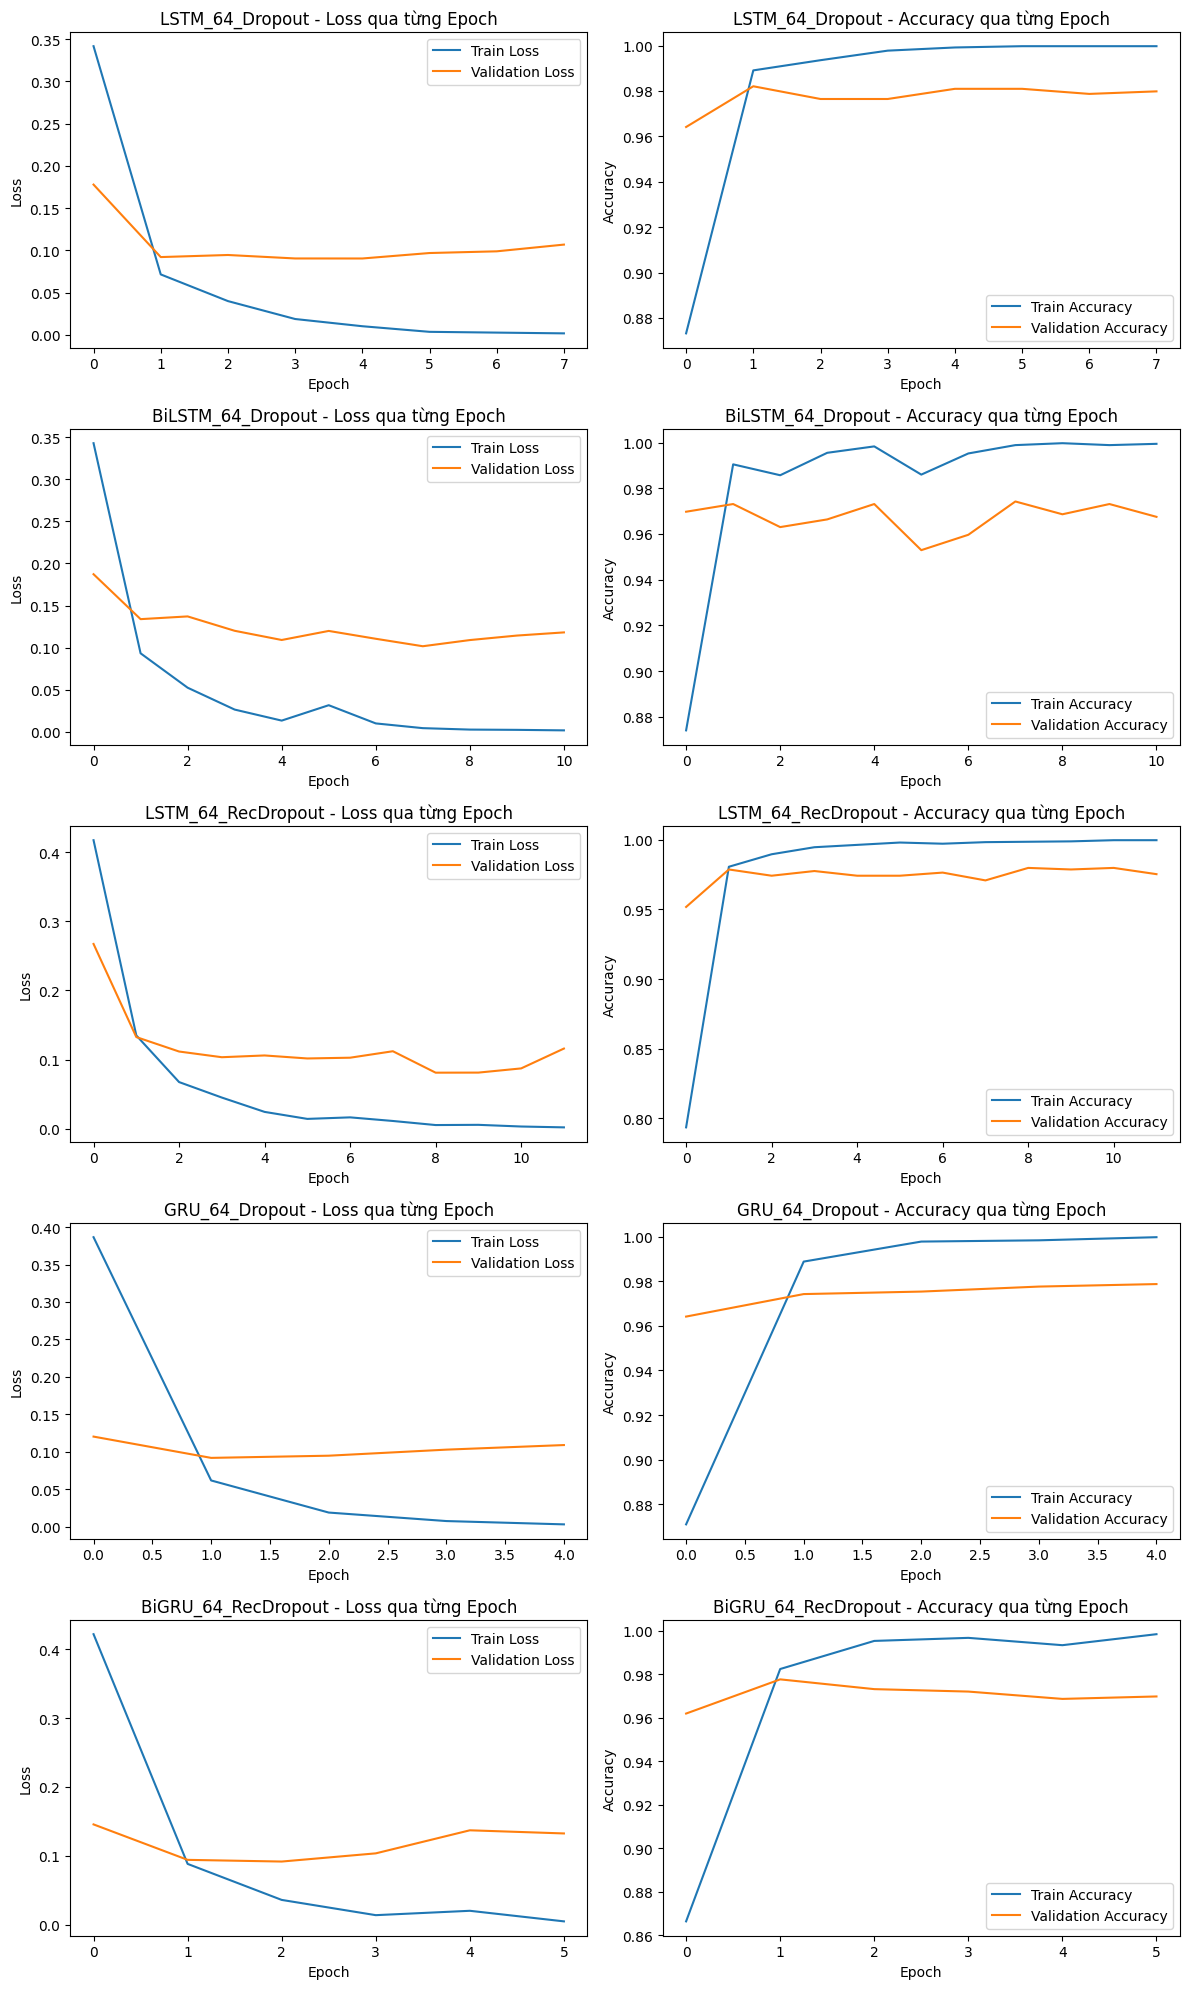

In [8]:
fig, axes = plt.subplots(len(configs), 2, figsize=(12, 4 * len(configs)))
for i, cfg in enumerate(configs):
    name = cfg['name']
    h = histories[name].history
    axes[i, 0].plot(h['loss'], label='Train Loss')
    axes[i, 0].plot(h['val_loss'], label='Validation Loss')
    axes[i, 0].set_title(f'{name} - Loss qua từng Epoch')
    axes[i, 0].set_xlabel('Epoch'); axes[i, 0].set_ylabel('Loss'); axes[i, 0].legend()

    axes[i, 1].plot(h['accuracy'], label='Train Accuracy')
    axes[i, 1].plot(h['val_accuracy'], label='Validation Accuracy')
    axes[i, 1].set_title(f'{name} - Accuracy qua từng Epoch')
    axes[i, 1].set_xlabel('Epoch'); axes[i, 1].set_ylabel('Accuracy'); axes[i, 1].legend()
plt.tight_layout()
plt.show()

Mô hình tốt nhất theo F1-score Spam: BiLSTM_64_Dropout
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step

Classification Report:
              precision    recall  f1-score   support

         Ham       0.99      0.99      0.99       966
        Spam       0.94      0.93      0.94       149

    accuracy                           0.98      1115
   macro avg       0.96      0.96      0.96      1115
weighted avg       0.98      0.98      0.98      1115



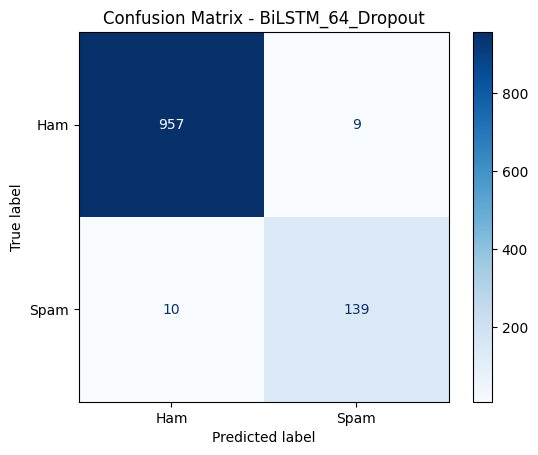

In [9]:
best_name = comparison_df.iloc[0]['Cấu hình']
best_model = models[best_name]
print(f"Mô hình tốt nhất theo F1-score Spam: {best_name}")

Y_pred_prob = best_model.predict(X_test)
Y_pred_best = (Y_pred_prob > 0.5).astype(int).flatten()

print("\nClassification Report:")
print(classification_report(Y_test, Y_pred_best, target_names=['Ham', 'Spam']))

cm = confusion_matrix(Y_test, Y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Ham', 'Spam'])
disp.plot(cmap='Blues')
plt.title(f'Confusion Matrix - {best_name}')
plt.show()

## 5. So sánh LSTM vs GRU 

So sánh trực tiếp cặp cấu hình tương đồng nhất để tách bạch ảnh hưởng của loại cell (LSTM vs GRU), tách biệt khỏi ảnh hưởng của Bidirectional/Recurrent Dropout:
- `LSTM_64_Dropout` vs `GRU_64_Dropout` (cùng kiến trúc, chỉ khác cell)
- Thời gian huấn luyện: so sánh số epoch thực chạy và thời gian mỗi epoch (xem log huấn luyện ở trên).

GRU có ít cổng hơn LSTM (2 gate thay vì 3, không có cell state riêng), nên **thường huấn luyện nhanh hơn** và có ít tham số hơn ở cùng số units — đổi lại khả năng biểu diễn có thể kém linh hoạt hơn một chút với chuỗi dài. Với câu SMS ngắn (~15-20 từ sau làm sạch), khác biệt hiệu năng giữa 2 loại cell thường không lớn — hãy điền số liệu thật vào bảng dưới sau khi chạy xong để kết luận cụ thể cho bộ dữ liệu này.

In [10]:
lstm_row = comparison_df[comparison_df['Cấu hình'] == 'LSTM_64_Dropout'].iloc[0]
gru_row = comparison_df[comparison_df['Cấu hình'] == 'GRU_64_Dropout'].iloc[0]

pd.DataFrame([lstm_row, gru_row])[
    ['Cấu hình', 'Số Epoch thực chạy', 'Số tham số', 'Test Accuracy', 'F1-score Spam']
]

,Cấu hình,Số Epoch thực chạy,Số tham số,Test Accuracy,F1-score Spam
1,LSTM_64_Dropout,8,673089,0.9830,0.9352
3,GRU_64_Dropout,5,665025,0.9776,0.9158
